In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import EarlyStopping, ModelCheckpoint


# ============================================================
# Locate project root
# ============================================================

current_dir = Path.cwd()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate project root containing 'src'."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


# ============================================================
# Project imports
# ============================================================

from src.preprocessing import (
    clean_market_data,
    temporal_split
)

from src.feature_engineering import (
    add_technical_indicators,
    create_sequences
)

from src.model import build_lstm_model
from src.utils import load_config


print("Project root:", PROJECT_ROOT)

Project root: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction


In [2]:
config = load_config("config/config.yaml")

time_steps = config["data"]["time_steps"]

units = config["model"]["units"]
learning_rate = config["model"]["learning_rate"]
epochs = config["model"]["epochs"]
batch_size = config["model"]["batch_size"]

print("Time steps:", time_steps)
print("LSTM units:", units)
print("Learning rate:", learning_rate)
print("Epochs:", epochs)
print("Batch size:", batch_size)

Time steps: 10
LSTM units: 256
Learning rate: 0.0005
Epochs: 50
Batch size: 32


In [3]:
data_path = (
    PROJECT_ROOT
    / "data"
    / "sample"
    / "test_crypto_data.csv"
)

print("Dataset:", data_path)
print("Exists:", data_path.exists())

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\data\sample\test_crypto_data.csv
Exists: True
Dataset shape: (7097, 7)


,Date,Asset,Open,High,Low,Close,Volume
0,2014-09-17,BTC-USD,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,BTC-USD,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,BTC-USD,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,BTC-USD,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,BTC-USD,408.084991,412.425995,393.181000,398.821014,26580100


In [4]:
df = clean_market_data(df)

featured_df = add_technical_indicators(df)

print("Shape after feature engineering:")
print(featured_df.shape)

print("\nAssets:")
print(featured_df["Asset"].value_counts())

featured_df.head()

Shape after feature engineering:
(7039, 14)

Assets:
Asset
BTC-USD    4094
ETH-USD    2945
Name: count, dtype: int64


,Date,Asset,Open,High,Low,Close,Volume,SMA_10,SMA_30,EMA_5,EMA_20,RSI_14,MACD,MACD_Signal
0,2014-10-16,BTC-USD,394.518005,398.807007,373.070007,382.556000,26990000,372.517606,384.112801,385.146292,379.667276,52.336359,-7.086205,-14.590592
1,2014-10-17,BTC-USD,382.756012,385.477997,375.389008,383.757996,13600700,377.274704,381.660267,384.683526,380.056869,58.314477,-6.039892,-12.880452
2,2014-10-18,BTC-USD,383.976013,395.157990,378.971008,391.441986,11416800,381.124902,380.560333,386.936346,381.141166,75.469711,-4.538333,-11.212028
3,2014-10-19,BTC-USD,391.253998,393.938995,386.457001,389.545990,5914570,383.576901,380.385333,387.806228,381.941625,79.658722,-3.461426,-9.661908
4,2014-10-20,BTC-USD,389.230988,390.084015,378.252014,382.845001,16419000,385.705200,379.516700,386.152485,382.027661,73.241668,-3.112802,-8.352087


In [5]:
eth_df = (
    featured_df[
        featured_df["Asset"] == "ETH-USD"
    ]
    .copy()
    .sort_values("Date")
    .reset_index(drop=True)
)

print("ETH observations:", len(eth_df))
print("Start:", eth_df["Date"].min())
print("End:", eth_df["Date"].max())

ETH observations: 2945
Start: 2017-12-08 00:00:00
End: 2025-12-30 00:00:00


In [6]:
FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "SMA_10",
    "SMA_30",
    "EMA_5",
    "EMA_20",
    "RSI_14",
    "MACD",
    "MACD_Signal"
]

TARGET_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close"
]

print("Number of features:", len(FEATURE_COLUMNS))
print("Targets:", TARGET_COLUMNS)

Number of features: 12
Targets: ['Open', 'High', 'Low', 'Close']


In [7]:
train_df, validation_df, test_df = temporal_split(
    eth_df,
    train_ratio=0.80,
    validation_ratio=0.10
)

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 2356
Validation: 294
Test: 295


In [8]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()


# Fit ONLY on training data
feature_scaler.fit(
    train_df[FEATURE_COLUMNS]
)

target_scaler.fit(
    train_df[TARGET_COLUMNS]
)


# Transform
train_features = feature_scaler.transform(
    train_df[FEATURE_COLUMNS]
)

validation_features = feature_scaler.transform(
    validation_df[FEATURE_COLUMNS]
)

test_features = feature_scaler.transform(
    test_df[FEATURE_COLUMNS]
)


train_targets = target_scaler.transform(
    train_df[TARGET_COLUMNS]
)

validation_targets = target_scaler.transform(
    validation_df[TARGET_COLUMNS]
)

test_targets = target_scaler.transform(
    test_df[TARGET_COLUMNS]
)

In [9]:
x_train, y_train = create_sequences(
    train_features,
    train_targets,
    time_steps=time_steps
)

x_validation, y_validation = create_sequences(
    validation_features,
    validation_targets,
    time_steps=time_steps
)

x_test, y_test = create_sequences(
    test_features,
    test_targets,
    time_steps=time_steps
)


print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_validation:", x_validation.shape)
print("y_validation:", y_validation.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (2346, 10, 12)
y_train: (2346, 4)
x_validation: (284, 10, 12)
y_validation: (284, 4)
x_test: (285, 10, 12)
y_test: (285, 4)


In [10]:

DATA_DIR = Path("../data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

np.save(DATA_DIR / "x_test.npy", x_test)
np.save(DATA_DIR / "y_test.npy", y_test)

In [11]:
model = build_lstm_model(
    input_shape=(
        x_train.shape[1],
        x_train.shape[2]
    ),
    units=units,
    output_size=y_train.shape[1],
    learning_rate=learning_rate
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 256)        │       275,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 817,476 (3.12 MB)

 Trainable params: 817,476 (3.12 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
best_model_path = (
    PROJECT_ROOT
    / "models"
    / "best_eth_lstm.keras"
)

best_model_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [13]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(
        x_validation,
        y_validation
    ),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0081
Epoch 1: val_loss improved from None to 0.00712, saving model to e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\models\best_eth_lstm.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0101 - val_loss: 0.0071
Epoch 2/50
72/74 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0172
Epoch 2: val_loss did not improve from 0.00712
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0144 - val_loss: 0.0082
Epoch 3/50
73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0266
Epoch 3: val_loss improved from 0.00712 to 0.00532, saving model to e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\models\best_eth_lstm.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0225 - val_loss: 0.0053
Epoch 4/50
70/74 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0173
Epoch 4: val_loss improved from 0.00532 to 0.00465, saving model to e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\models\best_eth_lstm.keras
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/

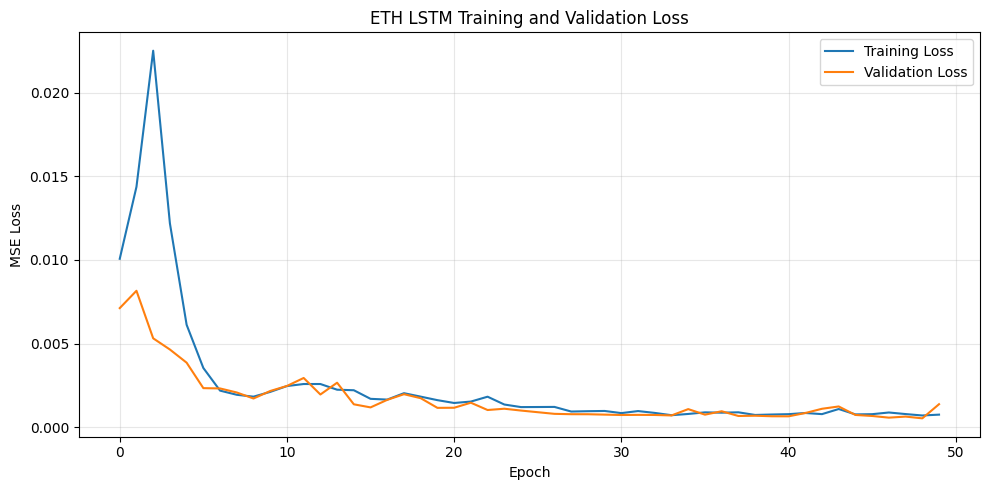

Saved: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction\results\figures\ETH_Training_Loss.png


In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ETH LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "ETH_Training_Loss.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure_path)